# EDA — dunnhumby “The Complete Journey”

This notebook prepares a unified dataset that can power the full DIF‑PI pipeline:
- Customer NPD from household transaction logs
- Price-demand time series derived from the same transactions for scenario generation (TBWISA)

## Why this dataset?
“The Complete Journey” is explicitly positioned for advanced classroom settings and academic research and includes household transactions and marketing context.

## Input
Place the raw CSVs under: `datasets/raw/complete_journey/`

This notebook supports two common formats:

##### A) Kaggle “dunnhumby-the-complete-journey” export
Typically includes files:
- `transaction_data.csv` (main transaction fact table)
- `product.csv`, `hh_demographic.csv`, `campaign_desc.csv`, etc.

##### B) R `completejourney` package export (full transactions)
A CSV such as:
- `transactions.csv` with columns:
  `household_id, store_id, basket_id, product_id, quantity, sales_value, ...`

## Output
Written to:

```text
datasets/processed/
├── difpi_transactions.csv        # standardized transactional logs for NPD
├── difpi_pricing_demand.csv      # derived daily series for one product_id (for scenarios)
└── difpi_metadata.json           # chosen product_id, basic stats
```

The DIF‑PI notebook will then use:
- `TX_PATH = datasets/processed/difpi_transactions.csv`
- (optional) `pricing_demand.csv` if pre-built series are preferred


## 1) Configuration

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json

REPO_ROOT = Path('.').resolve()
RAW_DIR = REPO_ROOT / 'datasets' / 'raw' / 'complete_journey'
OUT_DIR = REPO_ROOT / 'datasets' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# For datasets with integer 'day' fields, it needs an origin date to create a datetime axis
ORIGIN_DATE = pd.Timestamp('2018-01-01')

# Output filenames
TX_OUT = OUT_DIR / 'difpi_transactions.csv'
TS_OUT = OUT_DIR / 'difpi_pricing_demand.csv'
META_OUT = OUT_DIR / 'difpi_metadata.json'

print('RAW_DIR:', RAW_DIR)
print('OUT_DIR:', OUT_DIR)

# How many SKUs to export for panel time-series
TOP_N_SKUS = 300                  # typical range: 100–300 SKUs

# SKU selection filtering (keeps very sparse SKUs from dominating the panel)
SKU_SELECTION_MODE = 'eligible'   # 'top_quantity' or 'eligible'
MIN_ACTIVE_DAYS = 90              # relaxed default; increase for higher-quality series
MIN_NONZERO_DAYS = 20             # relaxed default; increase for higher-quality series

RAW_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/raw/complete_journey
OUT_DIR: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed


## 2) Load transactions

In [2]:
# Candidate filenames
candidates = [
    RAW_DIR / 'transaction_data.csv',
    RAW_DIR / 'transactions.csv',
    RAW_DIR / 'transactions_full.csv',
    RAW_DIR / 'transaction_data_full.csv',
]

path = next((p for p in candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        'Could not find a transactions file under datasets/raw/complete_journey/.\n'
        'Expected one of: transaction_data.csv, transactions.csv, transactions_full.csv.\n'
        'Download/export the dataset and place it there.'
    )

tx_raw = pd.read_csv(path)
print('Loaded:', path.name)
print('Rows:', len(tx_raw))
print('Columns:', list(tx_raw.columns)[:30], '...')
tx_raw.head()

Loaded: transaction_data.csv
Rows: 2595732
Columns: ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC'] ...


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


## 3) Standardize columns to DIF‑PI transactional schema

In [3]:
tx = tx_raw.copy()

# Column mapping (handles common variants)
def pick_col(cols, *options):
    cols_l = {c.lower(): c for c in cols}
    for opt in options:
        if opt.lower() in cols_l:
            return cols_l[opt.lower()]
    return None

col_household = pick_col(tx.columns, 'household_key', 'household_id', 'hh_id', 'customer_id')
col_day       = pick_col(tx.columns, 'day', 'DAY')
col_date      = pick_col(tx.columns, 'transaction_date', 'date', 'InvoiceDate', 'invoicedate')
col_prod      = pick_col(tx.columns, 'product_id', 'PRODUCT_ID', 'upc', 'StockCode', 'stockcode')
col_qty       = pick_col(tx.columns, 'quantity', 'QUANTITY', 'qty', 'Quantity')
col_sales     = pick_col(tx.columns, 'sales_value', 'SALES_VALUE', 'sales', 'SalesValue')
col_unitp     = pick_col(tx.columns, 'unit_price', 'UnitPrice', 'unitprice', 'price')

missing = [n for n,c in [('household',col_household),('product',col_prod),('quantity',col_qty)] if c is None]
if missing:
    raise ValueError(f'Missing required columns after mapping: {missing}. '
                     f'Please inspect your transaction file columns.')

# Build InvoiceDate
if col_date is not None:
    invoice_dt = pd.to_datetime(tx[col_date], errors='coerce')
elif col_day is not None:
    invoice_dt = ORIGIN_DATE + pd.to_timedelta(tx[col_day].astype(float), unit='D')
else:
    raise ValueError('No date information found. Need either a date column or an integer day column.')

# Unit price
if col_unitp is not None:
    unit_price = pd.to_numeric(tx[col_unitp], errors='coerce')
elif col_sales is not None:
    sales = pd.to_numeric(tx[col_sales], errors='coerce')
    qty = pd.to_numeric(tx[col_qty], errors='coerce')
    unit_price = sales / qty.replace({0: np.nan})
else:
    raise ValueError('No price fields found. Need either unit_price or (sales_value and quantity).')

qty = pd.to_numeric(tx[col_qty], errors='coerce')
prod = tx[col_prod].astype(str)
cust = tx[col_household].astype(str)

tx_std = pd.DataFrame({
    'CustomerID': cust,
    'InvoiceDate': invoice_dt,
    'StockCode': prod,
    'Quantity': qty,
    'UnitPrice': unit_price
})

# Basic cleaning: drop invalid rows, handle returns/cancellations (quantity<=0 or price<=0)
tx_std = tx_std.dropna(subset=['CustomerID','InvoiceDate','StockCode','Quantity','UnitPrice'])
tx_std = tx_std[(tx_std['Quantity'] > 0) & (tx_std['UnitPrice'] > 0)]
tx_std['InvoiceDate'] = pd.to_datetime(tx_std['InvoiceDate']).dt.floor('D')

print('Standardized rows:', len(tx_std))
tx_std.head()

Standardized rows: 2576815


,CustomerID,InvoiceDate,StockCode,Quantity,UnitPrice
0,2375,2018-01-02,1004906,1,1.39
1,2375,2018-01-02,1033142,1,0.82
2,2375,2018-01-02,1036325,1,0.99
3,2375,2018-01-02,1082185,1,1.21
4,2375,2018-01-02,8160430,1,1.50


## 4) EDA — overall stats

In [4]:
n_cust = tx_std['CustomerID'].nunique()
n_prod = tx_std['StockCode'].nunique()
date_min, date_max = tx_std['InvoiceDate'].min(), tx_std['InvoiceDate'].max()

print('Customers:', n_cust)
print('Products :', n_prod)
print('Date span:', date_min, '→', date_max)
print('Rows     :', len(tx_std))

Customers: 2500
Products : 91905
Date span: 2018-01-02 00:00:00 → 2019-12-13 00:00:00
Rows     : 2576815


In [5]:
# purchase events per customer (daily)
events_per_cust = (tx_std.groupby(['CustomerID','InvoiceDate'])
                         .size()
                         .reset_index(name='n_lines')
                         .groupby('CustomerID')
                         .size()
                         .rename('n_purchase_days'))

events_per_cust.describe(percentiles=[0.5,0.75,0.9,0.95])

count    2500.000000
mean       90.113600
std        76.259702
min         1.000000
50%        70.000000
75%       124.000000
90%       189.000000
95%       244.050000
max       521.000000
Name: n_purchase_days, dtype: float64

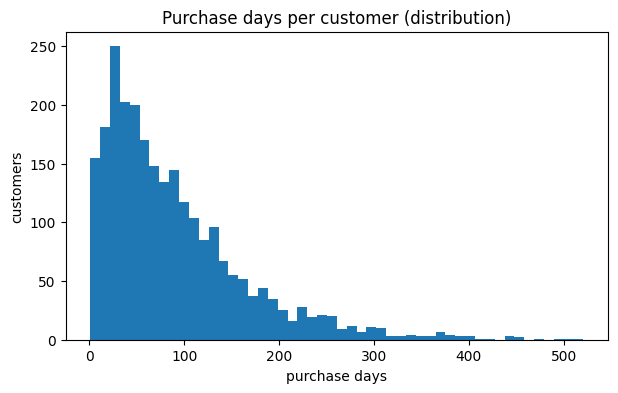

Customers with >=7 purchase days: 2438 / 2500


In [6]:
plt.figure(figsize=(7,4))
plt.hist(events_per_cust.values, bins=50)
plt.title('Purchase days per customer (distribution)')
plt.xlabel('purchase days'); plt.ylabel('customers')
plt.show()

print('Customers with >=7 purchase days:', int((events_per_cust>=7).sum()), '/', len(events_per_cust))

## 5) Choose a product for price-demand time series

In [7]:
# SKU pool selection for panel export
# Ranking SKUs by total quantity, with an optional eligibility filter to avoid extremely sparse series.

daily_qty = (tx_std.groupby(['StockCode', 'InvoiceDate'], as_index=False)['Quantity']
                 .sum()
                 .rename(columns={'Quantity': 'daily_qty'}))

sku_stats = (daily_qty.groupby('StockCode', as_index=True)
                    .agg(
                        total_qty=('daily_qty', 'sum'),
                        active_days=('InvoiceDate', 'nunique'),
                        nonzero_days=('daily_qty', lambda x: int((x > 0).sum()))
                    )
                    .sort_values('total_qty', ascending=False))

if SKU_SELECTION_MODE == 'eligible':
    sku_stats_sel = sku_stats[(sku_stats['active_days'] >= MIN_ACTIVE_DAYS) &
                              (sku_stats['nonzero_days'] >= MIN_NONZERO_DAYS)]
else:
    sku_stats_sel = sku_stats

print(f"SKU_SELECTION_MODE={SKU_SELECTION_MODE} | eligible={len(sku_stats_sel)}/{len(sku_stats)} | exporting up to TOP_N_SKUS={TOP_N_SKUS}")

# Keep the chosen panel SKUs
TOP_SKUS = list(sku_stats_sel.head(TOP_N_SKUS).index.astype(str))

# Preview
display(sku_stats_sel.head(20))

SKU_SELECTION_MODE=eligible | eligible=5381/91905 | exporting up to TOP_N_SKUS=300


,total_qty,active_days,nonzero_days
StockCode,,,
6534178,216532156,691,691
6533889,18479630,576,576
6534166,13980451,556,556
6544236,2705127,123,123
1404121,1694604,152,152
397896,1336257,112,112
1082185,30894,708,708
995242,21758,703,703
1029743,16972,708,708


In [8]:
# Export the selected SKU list
print('TOP_SKUS count:', len(TOP_SKUS))
print('TOP_SKUS (first 10 shown):', TOP_SKUS[:10])

TOP_SKUS_OUT = OUT_DIR / 'top_skus.csv'
pd.DataFrame({'StockCode': TOP_SKUS}).to_csv(TOP_SKUS_OUT, index=False)
print('Wrote:', TOP_SKUS_OUT)

# Keep a default single SKU (for quick plots)
CHOSEN_SKU = str(TOP_SKUS[0]) if len(TOP_SKUS) else None
print('CHOSEN_SKU (default for plots):', CHOSEN_SKU)

TOP_SKUS count: 300
TOP_SKUS (first 10 shown): ['6534178', '6533889', '6534166', '6544236', '1404121', '397896', '1082185', '995242', '1029743', '1133018']
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/top_skus.csv
CHOSEN_SKU (default for plots): 6534178


## 6) Build derived daily time series for scenarios

In [9]:
sub = tx_std[tx_std['StockCode'] == CHOSEN_SKU].copy()

# demand = sum(quantity) per day
# price  = weighted average UnitPrice by quantity per day
g = (sub.groupby('InvoiceDate', as_index=False)
       .apply(lambda d: pd.Series({
           'demand': float(d['Quantity'].sum()),
           'price': float(np.average(d['UnitPrice'], weights=d['Quantity'])) if d['Quantity'].sum() > 0 else float(d['UnitPrice'].mean())
       }))
       .reset_index(drop=True)
       .rename(columns={'InvoiceDate':'timestamp'}))

# Ensure daily continuity
g = g.sort_values('timestamp').set_index('timestamp')
full = pd.date_range(g.index.min(), g.index.max(), freq='D')
g = g.reindex(full)
g.index.name = 'timestamp'
g['price'] = g['price'].ffill()
g['demand'] = g['demand'].fillna(0.0)
ts = g.reset_index()

ts.head(), ts.shape

/var/folders/8b/dr6bdc0n5pjd47xzpz9x5jy00000gn/T/ipykernel_59269/490249545.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


(   timestamp  demand     price
 0 2018-01-13  2456.0  0.002191
 1 2018-01-14  2416.0  0.002070
 2 2018-01-15  2728.0  0.002199
 3 2018-01-16  8737.0  0.002289
 4 2018-01-17     0.0  0.002289,
 (700, 3))

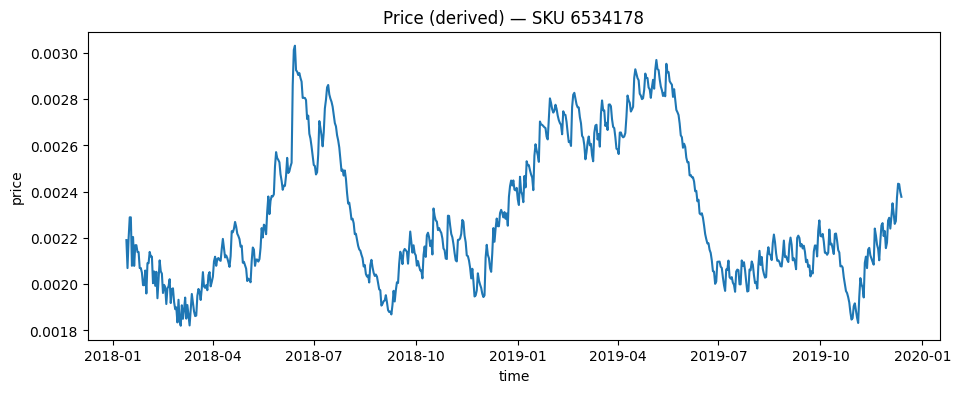

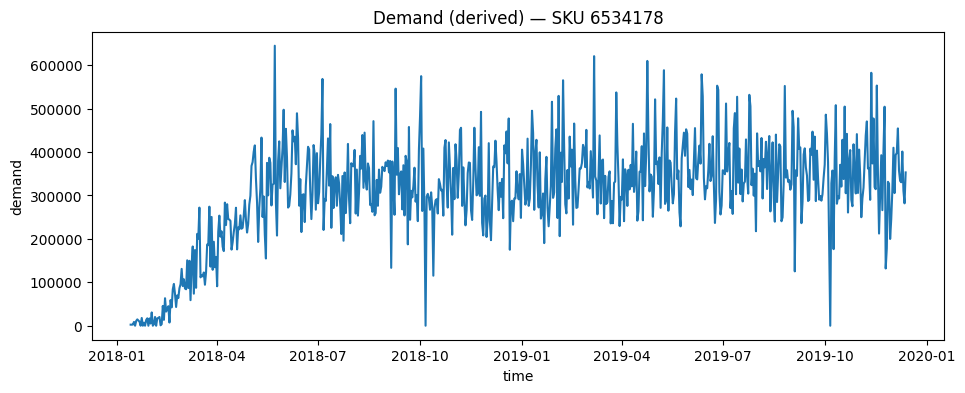

Pearson corr(price, demand): 0.26672260576251255


In [10]:
plt.figure(figsize=(11,4))
plt.plot(ts['timestamp'], ts['price'])
plt.title(f'Price (derived) — SKU {CHOSEN_SKU}')
plt.xlabel('time'); plt.ylabel('price')
plt.show()

plt.figure(figsize=(11,4))
plt.plot(ts['timestamp'], ts['demand'])
plt.title(f'Demand (derived) — SKU {CHOSEN_SKU}')
plt.xlabel('time'); plt.ylabel('demand')
plt.show()

corr = np.corrcoef(ts['price'].values, ts['demand'].values)[0,1]
print('Pearson corr(price, demand):', float(corr))

## 7) Build panel daily time series for TOP‑N SKUs

Exports a panel file:
- `difpi_pricing_demand_panel.csv` with columns: *timestamp, StockCode, price, demand*


In [11]:
PANEL_OUT = OUT_DIR / 'difpi_pricing_demand_panel.csv'

panel_rows = []
for sku in TOP_SKUS:
    sub = tx_std[tx_std['StockCode'] == sku].copy()
    if sub.empty:
        continue

    g = (sub.groupby('InvoiceDate', as_index=False)
           .apply(lambda d: pd.Series({
               'demand': float(d['Quantity'].sum()),
               'price': float(np.average(d['UnitPrice'], weights=d['Quantity'])) if d['Quantity'].sum() > 0 else float(d['UnitPrice'].mean())
           }))
           .reset_index(drop=True)
           .rename(columns={'InvoiceDate':'timestamp'}))

    # Ensure daily continuity per SKU
    g = g.sort_values('timestamp').set_index('timestamp')
    full = pd.date_range(g.index.min(), g.index.max(), freq='D')
    g = g.reindex(full)
    g.index.name = 'timestamp'
    g['price'] = g['price'].ffill()
    g['demand'] = g['demand'].fillna(0.0)
    g = g.reset_index()
    g['StockCode'] = str(sku)

    panel_rows.append(g[['timestamp','StockCode','price','demand']])

panel = pd.concat(panel_rows, ignore_index=True)
panel.to_csv(PANEL_OUT, index=False)

print('Panel rows:', len(panel))
print('Unique SKUs in panel:', panel['StockCode'].nunique())
print('Wrote:', PANEL_OUT)
panel.head()

/var/folders/8b/dr6bdc0n5pjd47xzpz9x5jy00000gn/T/ipykernel_59269/2997077705.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({
/var/folders/8b/dr6bdc0n5pjd47xzpz9x5jy00000gn/T/ipykernel_59269/2997077705.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({
/var/folders/8b/dr6bdc0n5pjd47xzpz9x5jy00000gn/T/ipykernel_59269/2997077705.py:10: Deprecation

Panel rows: 209633
Unique SKUs in panel: 300
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv


,timestamp,StockCode,price,demand
0,2018-01-13,6534178,0.002191,2456.0
1,2018-01-14,6534178,0.002070,2416.0
2,2018-01-15,6534178,0.002199,2728.0
3,2018-01-16,6534178,0.002289,8737.0
4,2018-01-17,6534178,0.002289,0.0


## 7b) Data regime analysis

The following block generates descriptive figures and summary tables for the retained SKU pool and for customer purchase timing behavior.


In [12]:
# Asset exports
EDA_OUT_DIR = OUT_DIR / 'eda_assets'
EDA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# SKU-level regime descriptors on the retained continuous panel
sku_panel_stats = (
    panel.sort_values(['StockCode', 'timestamp'])
         .groupby('StockCode', group_keys=False)
         .apply(
             lambda g: pd.Series({
                 'history_length': int(len(g)),
                 'active_day_count': int((g['demand'] > 0).sum()),
                 'active_day_ratio': float((g['demand'] > 0).mean()),
                 'zero_share': float((g['demand'] <= 0).mean()),
                 'price_change_count': int(g['price'].diff().fillna(0).ne(0).sum()),
                 'price_change_rate': float(
                     g['price'].diff().fillna(0).ne(0).sum() / max(len(g) - 1, 1)
                 ),
                 'mean_demand': float(g['demand'].mean()),
                 'std_demand': float(g['demand'].std(ddof=0)),
                 'first_date': str(g['timestamp'].min().date()),
                 'last_date': str(g['timestamp'].max().date())
             })
         )
         .reset_index()
)

sku_regime_descriptors_out = EDA_OUT_DIR / 'retained_sku_regime_descriptors.csv'
sku_panel_stats.to_csv(sku_regime_descriptors_out, index=False)

# Summary of the retained SKU pool after eligibility filtering
HIGH_INTERMITTENCY_ZERO_SHARE = 0.80
DENSE_ACTIVE_DAY_RATIO = 0.50

retained_sku_pool_summary = pd.DataFrame([
    {'summary_field': 'number_of_eligible_skus', 'value': int(sku_panel_stats['StockCode'].nunique())},
    {'summary_field': 'median_history_length', 'value': float(sku_panel_stats['history_length'].median())},
    {'summary_field': 'median_active_day_count', 'value': float(sku_panel_stats['active_day_count'].median())},
    {'summary_field': 'median_active_day_ratio', 'value': float(sku_panel_stats['active_day_ratio'].median())},
    {'summary_field': 'median_zero_share', 'value': float(sku_panel_stats['zero_share'].median())},
    {'summary_field': 'median_price_change_count', 'value': float(sku_panel_stats['price_change_count'].median())},
    {'summary_field': 'median_price_change_rate', 'value': float(sku_panel_stats['price_change_rate'].median())},
    {
        'summary_field': 'share_of_highly_intermittent_skus',
        'value': float((sku_panel_stats['zero_share'] >= HIGH_INTERMITTENCY_ZERO_SHARE).mean())
    },
    {
        'summary_field': 'share_of_dense_skus',
        'value': float((sku_panel_stats['active_day_ratio'] >= DENSE_ACTIVE_DAY_RATIO).mean())
    }
])

retained_sku_pool_summary_out = EDA_OUT_DIR / 'retained_sku_pool_summary.csv'
retained_sku_pool_summary.to_csv(retained_sku_pool_summary_out, index=False)

print('Wrote:', sku_regime_descriptors_out)
print('Wrote:', retained_sku_pool_summary_out)
display(retained_sku_pool_summary)
display(sku_panel_stats.head(20))

Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets/retained_sku_regime_descriptors.csv
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets/retained_sku_pool_summary.csv


/var/folders/8b/dr6bdc0n5pjd47xzpz9x5jy00000gn/T/ipykernel_59269/1778907441.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,summary_field,value
0,number_of_eligible_skus,300.000000
1,median_history_length,706.000000
2,median_active_day_count,530.500000
3,median_active_day_ratio,0.757234
4,median_zero_share,0.242766
5,median_price_change_count,224.000000
6,median_price_change_rate,0.317142
7,share_of_highly_intermittent_skus,0.010000
8,share_of_dense_skus,0.873333


,StockCode,history_length,active_day_count,active_day_ratio,zero_share,price_change_count,price_change_rate,mean_demand,std_demand,first_date,last_date
0,1000753,707,364,0.514851,0.485149,362,0.512748,1.786421,2.888976,2018-01-06,2019-12-13
1,1002558,701,488,0.696148,0.303852,241,0.344286,1.716120,1.817064,2018-01-12,2019-12-13
2,1003188,711,591,0.831224,0.168776,249,0.350704,3.388186,3.870779,2018-01-02,2019-12-13
3,1003421,697,389,0.558106,0.441894,188,0.270115,2.919656,5.594307,2018-01-11,2019-12-08
4,1003600,702,536,0.763533,0.236467,340,0.485021,3.700855,3.626269,2018-01-10,2019-12-12
5,1004906,711,590,0.829817,0.170183,449,0.632394,5.537271,5.404426,2018-01-02,2019-12-13
6,1005186,706,693,0.981586,0.018414,692,0.981560,7.450425,3.533884,2018-01-07,2019-12-13
7,1006184,710,562,0.791549,0.208451,182,0.256700,3.150704,3.323174,2018-01-03,2019-12-13
8,1007195,702,412,0.586895,0.413105,240,0.342368,14.314815,23.671645,2018-01-09,2019-12-11
9,1012873,697,403,0.578192,0.421808,14,0.020115,1.621234,2.162683,2018-01-15,2019-12-12


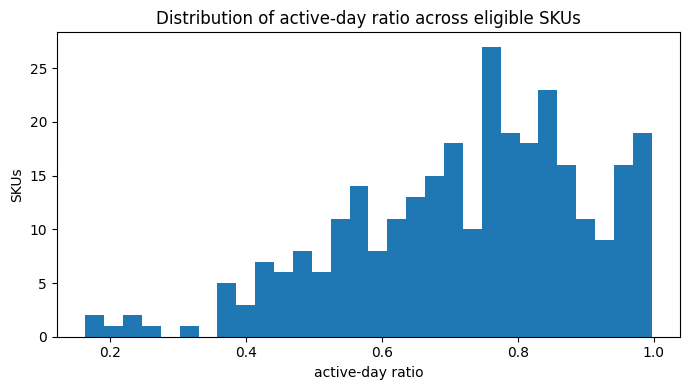

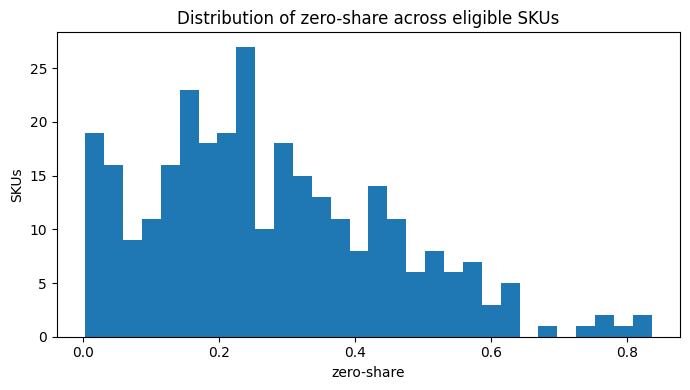

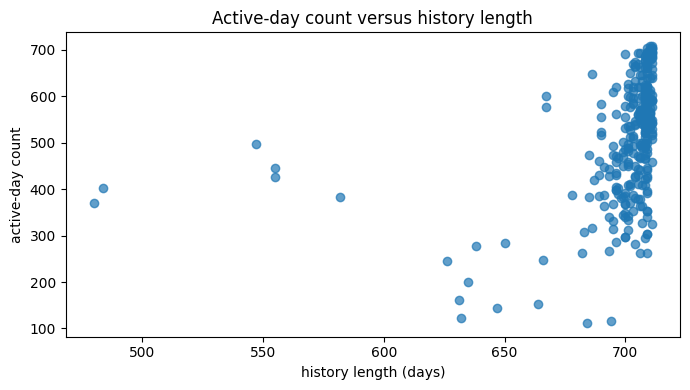

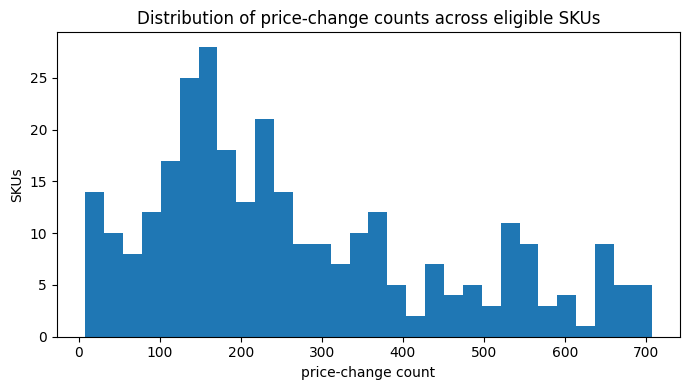

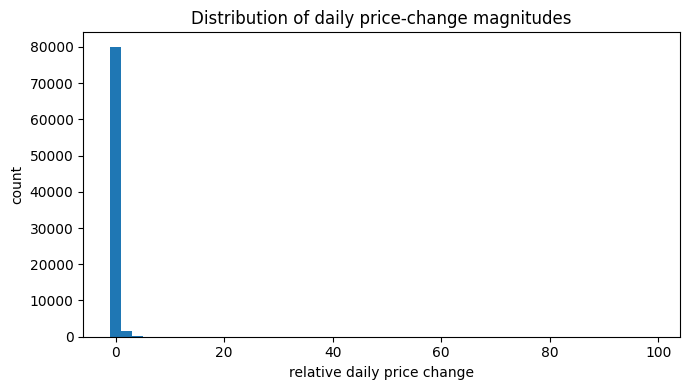

Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets/daily_price_change_magnitudes.csv


In [13]:
# Figure: distribution of active-day ratio across eligible SKUs
plt.figure(figsize=(7, 4))
plt.hist(sku_panel_stats['active_day_ratio'], bins=30)
plt.title('Distribution of active-day ratio across eligible SKUs')
plt.xlabel('active-day ratio')
plt.ylabel('SKUs')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'distribution_of_active_day_ratio_across_eligible_skus.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: distribution of zero-share across eligible SKUs
plt.figure(figsize=(7, 4))
plt.hist(sku_panel_stats['zero_share'], bins=30)
plt.title('Distribution of zero-share across eligible SKUs')
plt.xlabel('zero-share')
plt.ylabel('SKUs')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'distribution_of_zero_share_across_eligible_skus.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: active-day count versus history length
plt.figure(figsize=(7, 4))
plt.scatter(sku_panel_stats['history_length'], sku_panel_stats['active_day_count'], alpha=0.7)
plt.title('Active-day count versus history length')
plt.xlabel('history length (days)')
plt.ylabel('active-day count')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'active_day_count_versus_history_length.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: distribution of price-change counts across eligible SKUs
plt.figure(figsize=(7, 4))
plt.hist(sku_panel_stats['price_change_count'], bins=30)
plt.title('Distribution of price-change counts across eligible SKUs')
plt.xlabel('price-change count')
plt.ylabel('SKUs')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'distribution_of_price_change_counts_across_eligible_skus.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: distribution of daily price-change magnitudes
price_change_series = (
    panel.sort_values(['StockCode', 'timestamp'])
         .groupby('StockCode', group_keys=False)['price']
         .apply(lambda s: s.pct_change())
         .replace([np.inf, -np.inf], np.nan)
         .dropna()
)
price_change_series = price_change_series[price_change_series != 0]

price_change_magnitudes_out = EDA_OUT_DIR / 'daily_price_change_magnitudes.csv'
pd.DataFrame({'relative_price_change': price_change_series.values}).to_csv(price_change_magnitudes_out, index=False)

plt.figure(figsize=(7, 4))
plt.hist(price_change_series, bins=50)
plt.title('Distribution of daily price-change magnitudes')
plt.xlabel('relative daily price change')
plt.ylabel('count')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'distribution_of_daily_price_change_magnitudes.png', dpi=160, bbox_inches='tight')
plt.show()

print('Wrote:', price_change_magnitudes_out)

In [14]:
# Customer purchase timing descriptors from distinct purchase days
cust_purchase_days = (
    tx_std[['CustomerID', 'InvoiceDate']]
    .drop_duplicates()
    .sort_values(['CustomerID', 'InvoiceDate'])
    .copy()
)

cust_purchase_days['interpurchase_gap_days'] = (
    cust_purchase_days.groupby('CustomerID')['InvoiceDate']
    .diff()
    .dt.days
)

interpurchase_gaps = cust_purchase_days.dropna(subset=['interpurchase_gap_days']).copy()
interpurchase_gaps['interpurchase_gap_days'] = interpurchase_gaps['interpurchase_gap_days'].astype(int)

customer_purchase_regularity = (
    interpurchase_gaps.groupby('CustomerID')
    .agg(
        n_gaps=('interpurchase_gap_days', 'size'),
        mean_interpurchase_gap_days=('interpurchase_gap_days', 'mean'),
        std_interpurchase_gap_days=('interpurchase_gap_days', lambda s: float(s.std(ddof=0))),
        median_interpurchase_gap_days=('interpurchase_gap_days', 'median')
    )
    .reset_index()
)

customer_purchase_regularity['purchase_regularity_cv'] = (
    customer_purchase_regularity['std_interpurchase_gap_days'] /
    (customer_purchase_regularity['mean_interpurchase_gap_days'] + 1e-9)
)

customer_purchase_days_count = (
    cust_purchase_days.groupby('CustomerID')
    .size()
    .rename('purchase_day_count')
    .reset_index()
)

customer_purchase_regularity = customer_purchase_regularity.merge(
    customer_purchase_days_count, on='CustomerID', how='left'
)

activity_cut = customer_purchase_regularity['purchase_day_count'].median()
customer_purchase_regularity['customer_activity_segment'] = np.where(
    customer_purchase_regularity['purchase_day_count'] >= activity_cut,
    'high_activity',
    'low_activity'
)

interpurchase_gaps = interpurchase_gaps.merge(
    customer_purchase_regularity[['CustomerID', 'customer_activity_segment']],
    on='CustomerID',
    how='left'
)

customer_purchase_regularity_out = EDA_OUT_DIR / 'customer_purchase_regularity_scores.csv'
customer_purchase_regularity.to_csv(customer_purchase_regularity_out, index=False)

customer_interpurchase_gap_summary = pd.DataFrame([
    {'summary_field': 'number_of_customers_with_gaps', 'value': int(customer_purchase_regularity['CustomerID'].nunique())},
    {'summary_field': 'number_of_gap_observations', 'value': int(len(interpurchase_gaps))},
    {'summary_field': 'median_interpurchase_gap_days', 'value': float(interpurchase_gaps['interpurchase_gap_days'].median())},
    {'summary_field': 'mean_interpurchase_gap_days', 'value': float(interpurchase_gaps['interpurchase_gap_days'].mean())},
    {'summary_field': 'median_purchase_regularity_cv', 'value': float(customer_purchase_regularity['purchase_regularity_cv'].median())},
    {'summary_field': 'mean_purchase_regularity_cv', 'value': float(customer_purchase_regularity['purchase_regularity_cv'].mean())}
])

customer_interpurchase_gap_summary_out = EDA_OUT_DIR / 'customer_interpurchase_gap_summary.csv'
customer_interpurchase_gap_summary.to_csv(customer_interpurchase_gap_summary_out, index=False)

print('Wrote:', customer_purchase_regularity_out)
print('Wrote:', customer_interpurchase_gap_summary_out)
display(customer_interpurchase_gap_summary)
display(customer_purchase_regularity.head(20))


Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets/customer_purchase_regularity_scores.csv
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets/customer_interpurchase_gap_summary.csv


,summary_field,value
0,number_of_customers_with_gaps,2497.000000
1,number_of_gap_observations,222784.000000
2,median_interpurchase_gap_days,3.000000
3,mean_interpurchase_gap_days,6.948699
4,median_purchase_regularity_cv,0.992361
5,mean_purchase_regularity_cv,1.147294


,CustomerID,n_gaps,mean_interpurchase_gap_days,std_interpurchase_gap_days,median_interpurchase_gap_days,purchase_regularity_cv,purchase_day_count,customer_activity_segment
0,1,77,8.506494,4.551647,9.0,0.535079,78,high_activity
1,10,4,142.750000,138.252260,99.0,0.968492,5,low_activity
2,100,27,25.370370,23.736436,15.0,0.935597,28,low_activity
3,1000,126,5.214286,5.868408,4.5,1.125448,127,high_activity
4,1001,78,8.897436,13.685656,5.0,1.538157,79,high_activity
5,1002,27,23.629630,21.162770,17.0,0.895603,28,low_activity
6,1003,46,14.239130,14.790104,8.5,1.038694,47,low_activity
7,1004,210,2.980952,2.782534,2.0,0.933438,211,high_activity
8,1005,165,3.612121,3.740990,3.0,1.035677,166,high_activity
9,1006,9,67.666667,76.437338,37.0,1.129616,10,low_activity


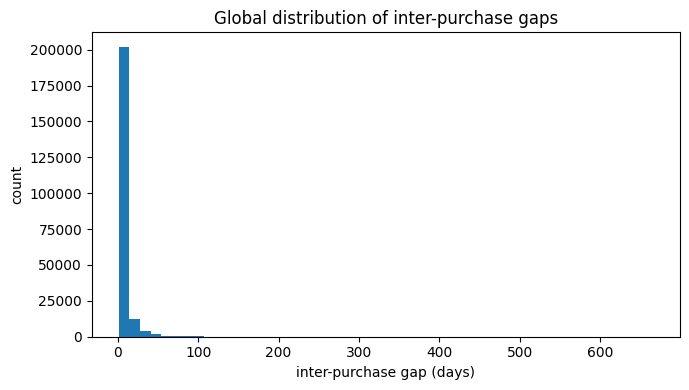

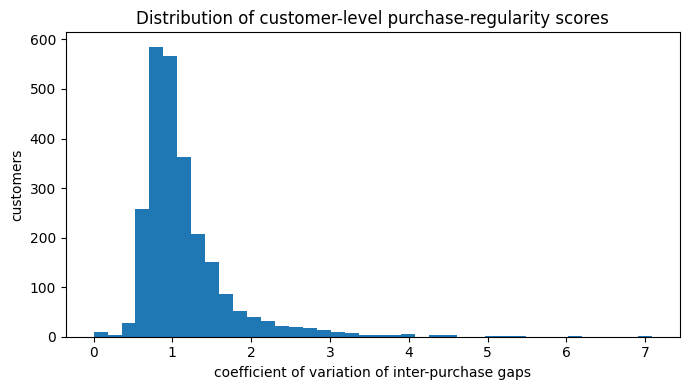

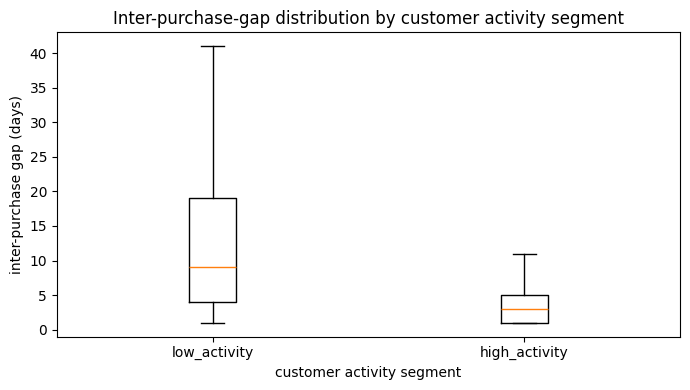

In [15]:
# Figure: global distribution of inter-purchase gaps
plt.figure(figsize=(7, 4))
plt.hist(interpurchase_gaps['interpurchase_gap_days'], bins=50)
plt.title('Global distribution of inter-purchase gaps')
plt.xlabel('inter-purchase gap (days)')
plt.ylabel('count')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'global_distribution_of_interpurchase_gaps.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: distribution of customer-level purchase-regularity scores
plt.figure(figsize=(7, 4))
regularity_values = customer_purchase_regularity['purchase_regularity_cv'].replace([np.inf, -np.inf], np.nan).dropna()
plt.hist(regularity_values, bins=40)
plt.title('Distribution of customer-level purchase-regularity scores')
plt.xlabel('coefficient of variation of inter-purchase gaps')
plt.ylabel('customers')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'distribution_of_customer_purchase_regularity_scores.png', dpi=160, bbox_inches='tight')
plt.show()

# Figure: inter-purchase-gap distribution by customer activity segment
segments = ['low_activity', 'high_activity']
plot_data = [
    interpurchase_gaps.loc[
        interpurchase_gaps['customer_activity_segment'] == seg,
        'interpurchase_gap_days'
    ].values
    for seg in segments
]

plt.figure(figsize=(7, 4))
plt.boxplot(plot_data, tick_labels=segments, showfliers=False)
plt.title('Inter-purchase-gap distribution by customer activity segment')
plt.xlabel('customer activity segment')
plt.ylabel('inter-purchase gap (days)')
plt.tight_layout()
plt.savefig(EDA_OUT_DIR / 'interpurchase_gap_distribution_by_customer_activity_segment.png', dpi=160, bbox_inches='tight')
plt.show()

In [16]:
eda_assets_written = [
    'retained_sku_regime_descriptors.csv',
    'retained_sku_pool_summary.csv',
    'daily_price_change_magnitudes.csv',
    'customer_purchase_regularity_scores.csv',
    'customer_interpurchase_gap_summary.csv',
    'distribution_of_active_day_ratio_across_eligible_skus.png',
    'distribution_of_zero_share_across_eligible_skus.png',
    'active_day_count_versus_history_length.png',
    'distribution_of_price_change_counts_across_eligible_skus.png',
    'distribution_of_daily_price_change_magnitudes.png',
    'global_distribution_of_interpurchase_gaps.png',
    'distribution_of_customer_purchase_regularity_scores.png',
    'interpurchase_gap_distribution_by_customer_activity_segment.png'
]

print('EDA assets written to:', EDA_OUT_DIR)
for name in eda_assets_written:
    print(' -', name)

EDA assets written to: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/eda_assets
 - retained_sku_regime_descriptors.csv
 - retained_sku_pool_summary.csv
 - daily_price_change_magnitudes.csv
 - customer_purchase_regularity_scores.csv
 - customer_interpurchase_gap_summary.csv
 - distribution_of_active_day_ratio_across_eligible_skus.png
 - distribution_of_zero_share_across_eligible_skus.png
 - active_day_count_versus_history_length.png
 - distribution_of_price_change_counts_across_eligible_skus.png
 - distribution_of_daily_price_change_magnitudes.png
 - global_distribution_of_interpurchase_gaps.png
 - distribution_of_customer_purchase_regularity_scores.png
 - interpurchase_gap_distribution_by_customer_activity_segment.png


## 8) Export processed files for DIF‑PI

In [17]:
tx_std.to_csv(TX_OUT, index=False)
ts.to_csv(TS_OUT, index=False)

meta = {
    'source_transactions_file': str(path.name),
    'chosen_sku': CHOSEN_SKU,
    'requested_top_n_skus': int(TOP_N_SKUS),
    'exported_top_n_skus': int(len(TOP_SKUS)),
    'sku_selection_mode': str(SKU_SELECTION_MODE),
    'min_active_days': int(MIN_ACTIVE_DAYS),
    'min_nonzero_days': int(MIN_NONZERO_DAYS),
    'top_skus_out': 'top_skus.csv',
    'panel_out': 'difpi_pricing_demand_panel.csv',
    'single_series_out': 'difpi_pricing_demand.csv',
    'n_customers': int(tx_std['CustomerID'].nunique()),
    'n_products': int(tx_std['StockCode'].nunique()),
    'date_min': str(tx_std['InvoiceDate'].min()),
    'date_max': str(tx_std['InvoiceDate'].max()),
    'rows_transactions': int(len(tx_std)),
    'rows_timeseries_single': int(len(ts)),
    'rows_timeseries_panel': int(len(panel)) if 'panel' in globals() else None
}
META_OUT.write_text(json.dumps(meta, indent=2), encoding='utf-8')

print('Wrote:', TX_OUT)
print('Wrote:', TS_OUT)
print('Wrote:', META_OUT)

Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_transactions.csv
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand.csv
Wrote: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_metadata.json
